**Objective**:
> Designing optimal one-day hiking routes
> Minimize effort; Maximize visited landmarks

Things to have into account:

* different levels of experience
* realistic constraints (ability, equipment, daylight)
* routes starting and ending at the same location
* winter and summer gear
* height and distance
* secret paths
* new non-existent connections (reasonable)

Displaying Graph 1. Close the window to see the next one.


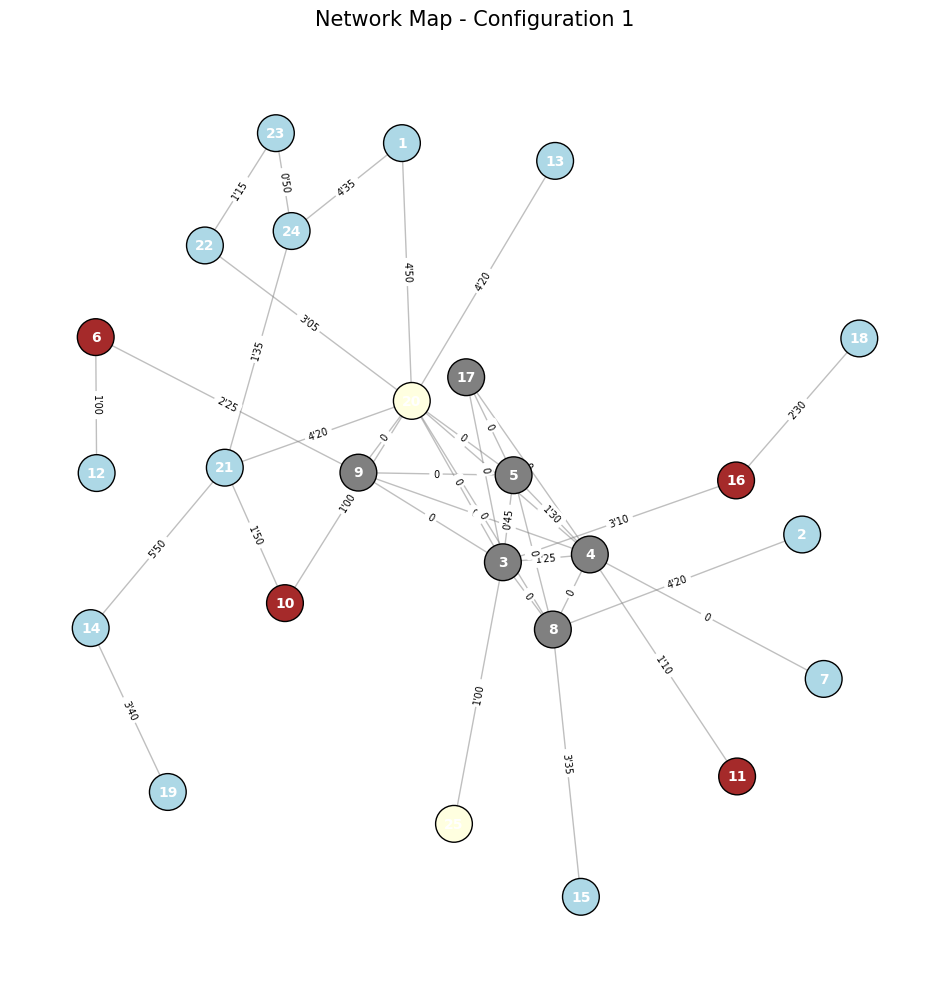

Displaying Graph 2. Close the window to see the next one.


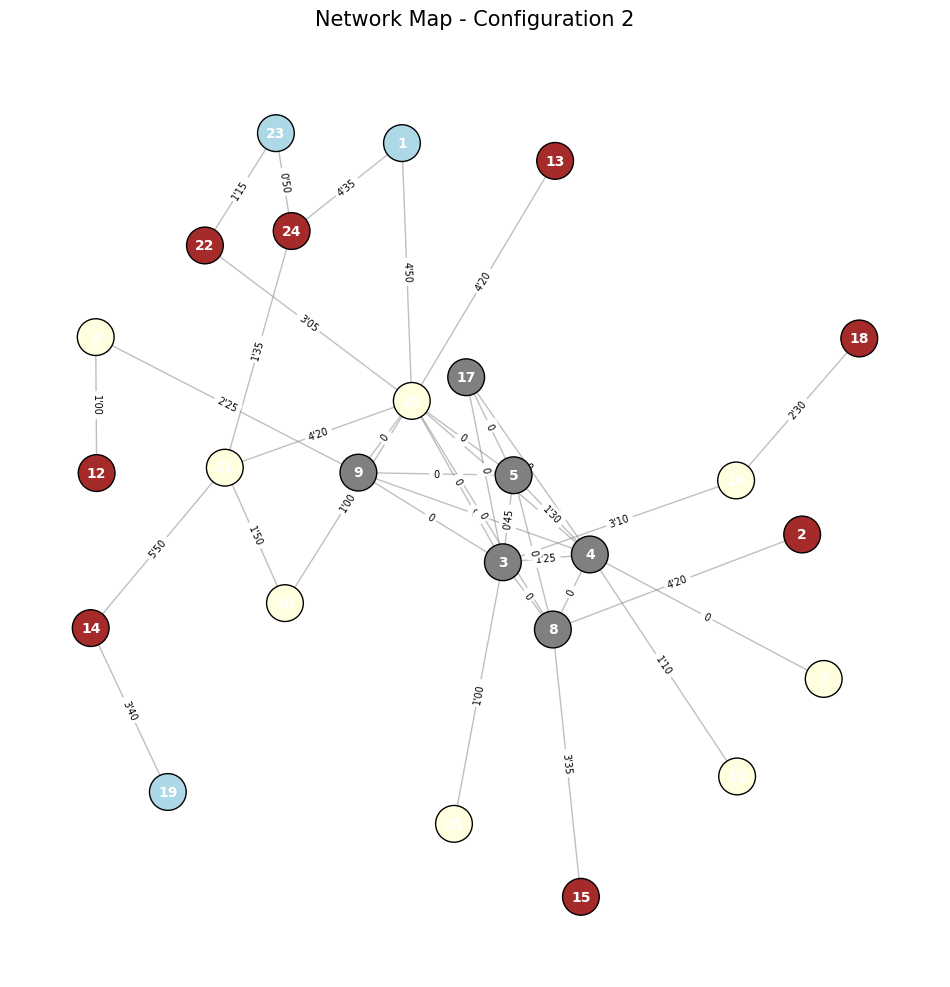

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

# 1. Load the distance matrix from a file (assuming it's saved as 'distances.csv')
# Adjust skiprows if your CSV doesn't have the two descriptive header rows
df_distances = pd.read_csv('194_hackaton_info/distances.csv', skiprows=2, index_col=0)

# 2. Build the Graph
G = nx.Graph()
nodes = [str(i) for i in range(1, 26)]
G.add_nodes_from(nodes)

for i in df_distances.index:
    for j in df_distances.columns:
        val = df_distances.loc[i, j]
        if pd.notna(val) and val != 'X' and str(val).strip() != '':
            G.add_edge(str(i), str(j), label=val)

# 3. Compute layout ONCE so both graphs have the exact same shape
pos = nx.spring_layout(G, weight=None, k=0.8, seed=42)

# 4. Load the colors CSV (assuming it's saved as 'colors.csv')
# header=None assumes the file is just the raw data without column names
df_colors = pd.read_csv('194_hackaton_info/clime.csv', header=None)

# Define a dictionary to map your values (1, 2, 3) to actual colors
# You can change these to any colors or hex codes you prefer
color_mapping = {
    'S': 'lightblue',
    'U': 'grey',
    'M': 'brown',
    'T': 'lightyellow'
}

for index, row in df_colors.iterrows():
    # Construct the color list based on the row values
    node_colors = []
    for node in G.nodes():
        # Node '1' is at index 0, Node '2' at index 1, etc.
        col_idx = int(node) - 1
        val = row[col_idx]
        node_colors.append(color_mapping.get(val, '#bdc3c7')) # default light gray

    plt.figure(figsize=(12, 12))
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, edgecolors='black')
    
    # Draw Labels (Node numbers)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
    
    # Draw Edge Labels (Time distances)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    
    plt.title(f'Network Map - Configuration {index + 1}', fontsize=15, pad=20)
    plt.axis('off')
    
    # Save the file
    plt.savefig(f'graph_config_{index + 1}.png', bbox_inches='tight', dpi=300)
    
    # Display the plot window
    print(f"Displaying Graph {index + 1}. Close the window to see the next one.")
    plt.show() 
    
    # Clear memory for the next plot
    plt.close()

Let's use some kind of "effort" metric, that will be computed doing: 

$$\mathcal{E}({(x^1_1, x^1_2), ..., (x^n_1, x^n_2)}) = \sum_{i=0}^n mean(x^i_1.type + x^i_2.type) \cdot distance(x^i_1, x^i_2) \cdot dif\_height(x^i_1, x^i_2)$$

With for $.type$ values coming from:

Clime | Value
---|---
`Urban`|0.2
`Trail`|0.4
`Mountain`|0.6
`Snow`|0.8


Distance and dif_height may be subject to `transformations`.

In [34]:
def elev_func(x) -> float:
    return 5.556*10**(-12)*x**3 + 3.889*10**(-8)*x**2 + 1

In [49]:
# Get heights
df_elevation = pd.read_csv('194_hackaton_info/elevation.csv', header=None)

# Flatten in case it has multiple rows
elevations = df_elevation.stack().reset_index(drop=True)

# Assign elevations in order of nodes
for i, node in enumerate(G.nodes):
        G.nodes[node]["elevation"] = elev_func(elevations[i])

In [50]:
# Mapping types to values: 
type_value_map = {
    "U": 0.2,
    "S": 0.8,
    "T": 0.4,
    "M": 0.6,
}

In [51]:
# Get types:
df_types = pd.read_csv("194_hackaton_info/clime.csv", header=None)
df_types = df_types.stack().reset_index(drop=True).to_frame(name="type")

# Assign type to each node
for i, node in enumerate(G.nodes):
    G.nodes[node]["type"] = float(type_value_map[df_types.loc[i, "type"]])

In [52]:
# Cost function: 

def cost_func(G, path, weight="weight", return_to_start=True):
    cost = 0.0
    
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        cost += (np.mean(float(G[u]["type"]), float(G[v]["type"])) 
                * float(G[u][v]["label"])   # label = time
                * (float(G[v]["elevation"])-float(G[u]["elevation"])))
    
    return cost

In [57]:
# Crude selection:

def select(G, Snow : bool):
    Pruned_graph = G.copy()
    for node in G.nodes:
        if Snow == False:
            if Pruned_graph.nodes[node]["type"] == type_value_map["S"]:
                Pruned_graph.remove_node(node)
    return Pruned_graph
    

Displaying Graph 1. Close the window to see the next one.


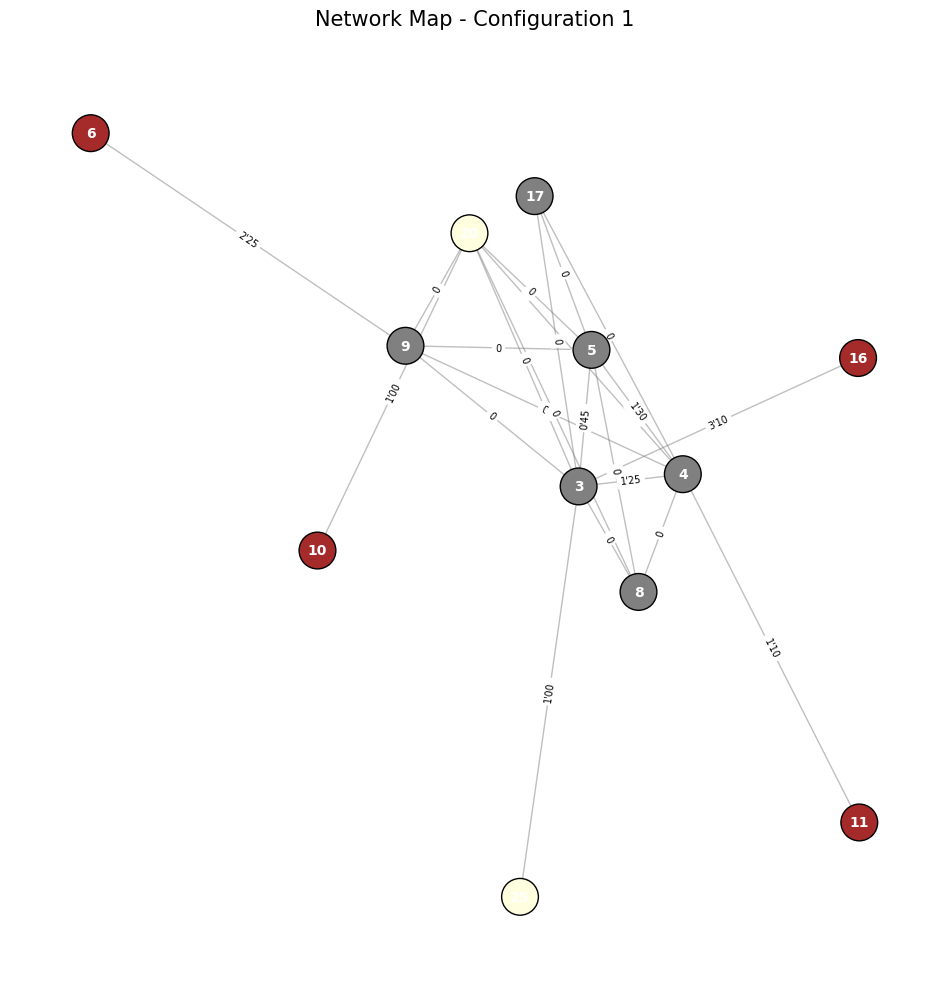

Displaying Graph 2. Close the window to see the next one.


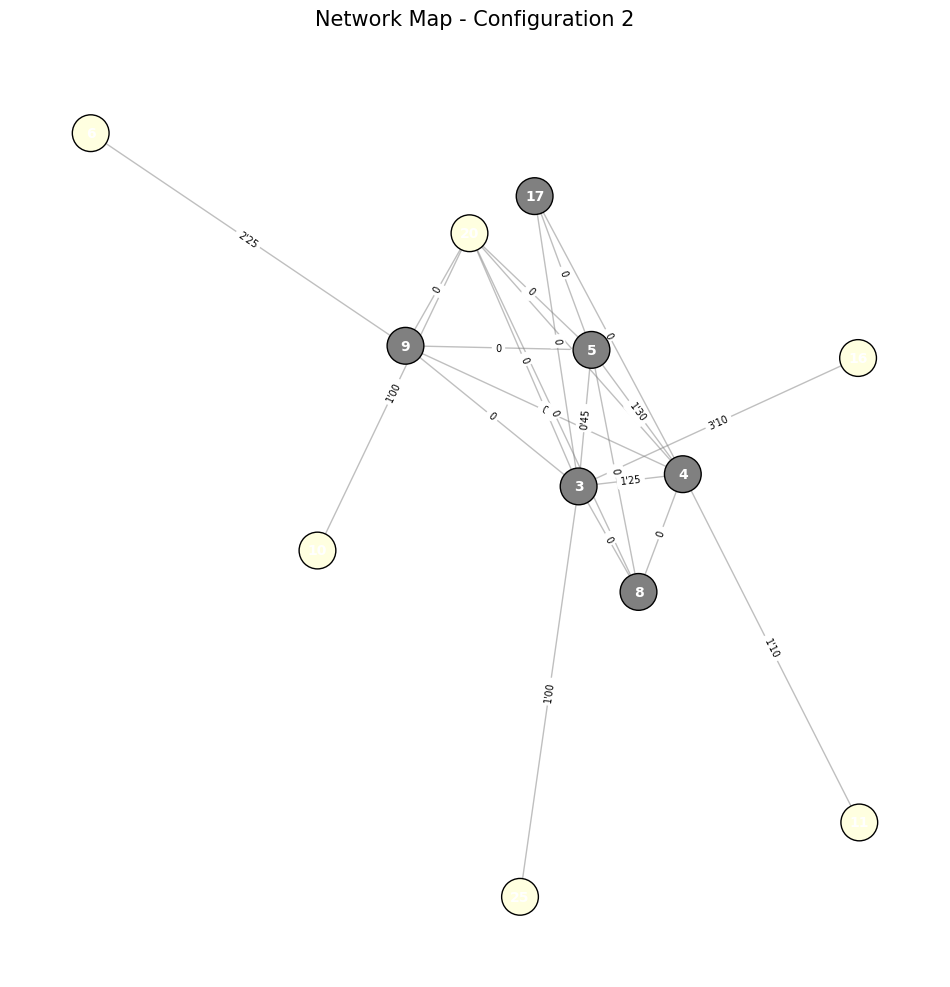

In [58]:
pruned_G = select(G, Snow = False)

for index, row in df_colors.iterrows():
    # Construct the color list based on the row values
    node_colors = []
    for node in pruned_G.nodes():
        # Node '1' is at index 0, Node '2' at index 1, etc.
        col_idx = int(node) - 1
        val = row[col_idx]
        node_colors.append(color_mapping.get(val, '#bdc3c7')) # default light gray

    plt.figure(figsize=(12, 12))
    
    # Draw Nodes
    nx.draw_networkx_nodes(pruned_G, pos, node_color=node_colors, node_size=700, edgecolors='black')
    
    # Draw Labels (Node numbers)
    nx.draw_networkx_labels(pruned_G, pos, font_size=10, font_weight='bold', font_color='white')
    
    # Draw Edges
    nx.draw_networkx_edges(pruned_G, pos, edge_color='gray', alpha=0.5)
    
    # Draw Edge Labels (Time distances)
    edge_labels = nx.get_edge_attributes(pruned_G, 'label')
    nx.draw_networkx_edge_labels(pruned_G, pos, edge_labels=edge_labels, font_size=7)
    
    plt.title(f'Network Map - Configuration {index + 1}', fontsize=15, pad=20)
    plt.axis('off')
    
    # Save the file
    plt.savefig(f'graph_config_{index + 1}.png', bbox_inches='tight', dpi=300)
    
    # Display the plot window
    print(f"Displaying Graph {index + 1}. Close the window to see the next one.")
    plt.show() 
    
    # Clear memory for the next plot
    plt.close()